# Elementary Cellular Automata

A visual exploration of 1D cellular automata using Wolfram's numbering system.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from automaton import ElementaryCA

In this notebook, we use an `ElementaryCA` class to handle the computation so we can focus on understanding the concepts. If you want to build one from scratch as an exercise, the core idea is simple: write a class where each cell looks at its own state and its neighbors' states, then uses a lookup table to decide what it becomes in the next timestep.

## 1. What is a Cellular Automaton?

Picture a row of squares, like graph paper. Each square is either filled (black, alive, 1) or empty (white, dead, 0).

Now pick any one square. To figure out what it becomes in the next generation, it looks at exactly three squares: itself, the square to its left, and the square to its right. That's the *neighborhood*.

These three squares together form a pattern. Since each is either 0 or 1, there are only 8 possible patterns (2 x 2 x 2 = 8).

A *rule* is just a lookup table that says: for each of these 8 patterns, what does the center cell become?

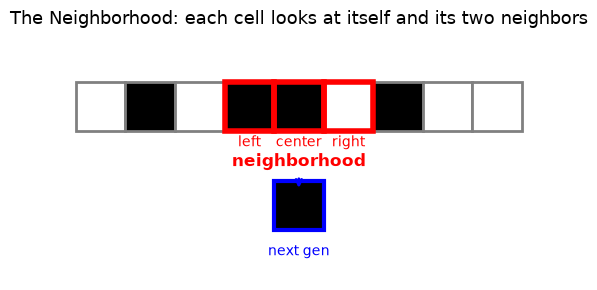

In [2]:
# Visual: show a row of cells with one highlighted neighborhood
fig, ax = plt.subplots(figsize=(12, 3))

# Draw a row of 9 cells
row = [0, 1, 0, 1, 1, 0, 1, 0, 0]
for i, val in enumerate(row):
    color = 'black' if val else 'white'
    rect = plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='gray', linewidth=2)
    ax.add_patch(rect)

# Highlight the neighborhood of cell 4 (indices 3, 4, 5)
for i in [3, 4, 5]:
    rect = plt.Rectangle((i, 0), 1, 1, facecolor='none', edgecolor='red', linewidth=4)
    ax.add_patch(rect)

# Label
ax.annotate('left', xy=(3.5, -0.3), ha='center', fontsize=10, color='red')
ax.annotate('center', xy=(4.5, -0.3), ha='center', fontsize=10, color='red')
ax.annotate('right', xy=(5.5, -0.3), ha='center', fontsize=10, color='red')
ax.annotate('neighborhood', xy=(4.5, -0.7), ha='center', fontsize=12, color='red', weight='bold')

# Arrow showing "this determines next state"
ax.annotate('', xy=(4.5, -1.2), xytext=(4.5, -0.9),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Next generation cell
next_rect = plt.Rectangle((4, -2.0), 1, 1, facecolor='black', edgecolor='blue', linewidth=3)
ax.add_patch(next_rect)
ax.annotate('next gen', xy=(4.5, -2.5), ha='center', fontsize=10, color='blue')

ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-3, 2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('The Neighborhood: each cell looks at itself and its two neighbors', fontsize=13)
plt.tight_layout()
plt.show()

## 2. The Wolfram Rule System

Stephen Wolfram came up with a clever numbering system for these rules. Since there are 8 possible
3-cell patterns, and each pattern maps to either 0 or 1, a complete rule is just 8 bits: a number
from 0 to 255.

The 8 patterns, ordered from 111 down to 000:

```
Pattern:   111  110  101  100  011  010  001  000
Index:      7    6    5    4    3    2    1    0
```

For **Rule 30**, the decimal number 30 in binary is `00011110`. Reading those bits left to right
gives the output for each pattern:

```
Pattern:   111  110  101  100  011  010  001  000
Output:     0    0    0    1    1    1    1    0
```

So "three alive neighbors" produces a dead cell, but "one alive on the right" produces a live cell.
Let's see this in action.

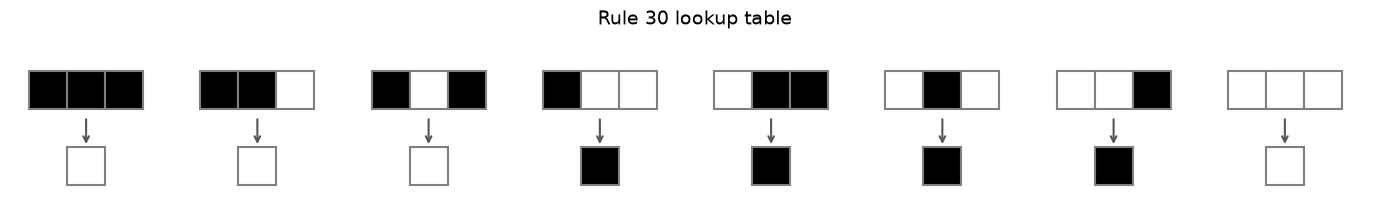

In [3]:
def draw_rule_table(rule, ax=None):
    """Draw a pixelated rule table showing all 8 neighborhood patterns and outputs."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))
    
    patterns = [(1,1,1), (1,1,0), (1,0,1), (1,0,0), (0,1,1), (0,1,0), (0,0,1), (0,0,0)]
    outputs = [(rule >> (7 - i)) & 1 for i in range(8)]
    
    for col, (pattern, output) in enumerate(zip(patterns, outputs)):
        x_offset = col * 4.5
        
        # Draw the 3-cell input pattern
        for i, val in enumerate(pattern):
            color = 'black' if val else 'white'
            rect = plt.Rectangle((x_offset + i, 2), 1, 1, facecolor=color, edgecolor='gray', linewidth=1.5)
            ax.add_patch(rect)
        
        # Arrow
        ax.annotate('', xy=(x_offset + 1.5, 1.0), xytext=(x_offset + 1.5, 1.8),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
        
        # Draw the output cell (centered below)
        out_color = 'black' if output else 'white'
        rect = plt.Rectangle((x_offset + 1, 0), 1, 1, facecolor=out_color, edgecolor='gray', linewidth=1.5)
        ax.add_patch(rect)
    
    ax.set_xlim(-0.5, 35.5)
    ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Rule {rule} lookup table', fontsize=14)
    return ax

fig, ax = plt.subplots(figsize=(14, 4))
draw_rule_table(30, ax)
plt.tight_layout()
plt.show()

In [4]:
# Text version for reference
print(ElementaryCA.rule_table_str(30))

Pattern  ->  Output
--------------------
  111    ->    0
  110    ->    0
  101    ->    0
  100    ->    1
  011    ->    1
  010    ->    1
  001    ->    1
  000    ->    0


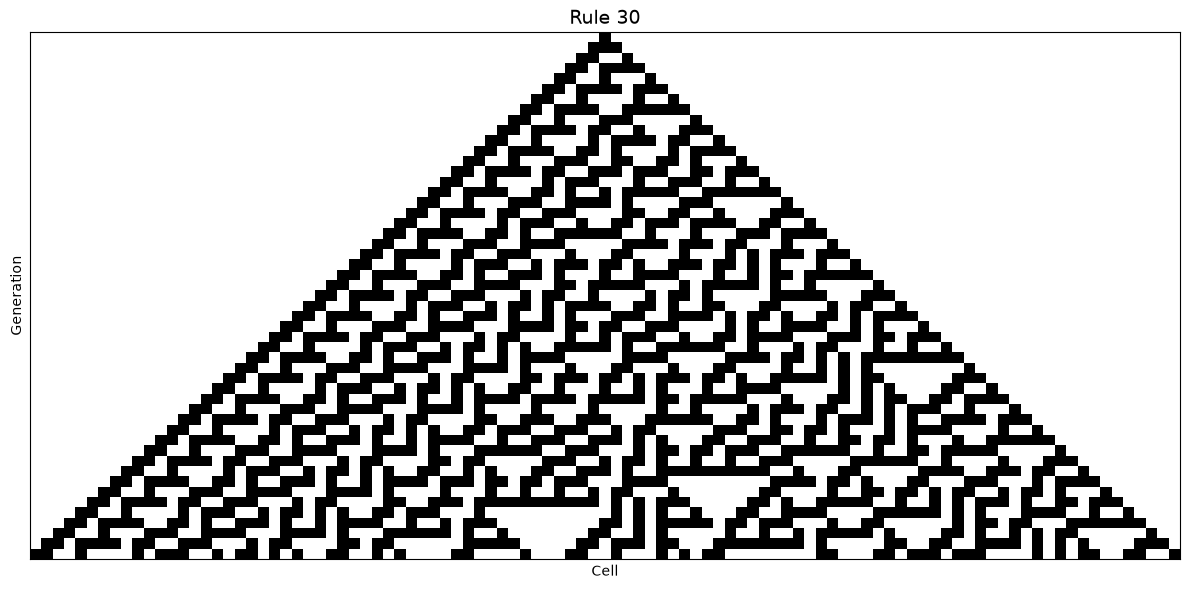

In [5]:
# Run Rule 30 starting from a single cell in the center
ca = ElementaryCA(rule=30, width=101, steps=50, init="single")
ca.run()

fig, ax = plt.subplots(figsize=(12, 6))
ca.plot(ax=ax)
plt.tight_layout()
plt.show()

From a single black cell, Rule 30 produces a chaotic, asymmetric triangle. The left side has
some nested structure, but the right side and center appear genuinely random. This pattern never
repeats, no matter how far you run it.

## 3. Explore Any Rule

Use the sliders below to try different rules and see what patterns they produce. Some will be
boring (all black or all white), some will make stripes, and some will surprise you.

In [6]:
import ipywidgets as widgets
from IPython.display import display

def show_rule(rule=30, init="single", width=201, steps=100):
    ca = ElementaryCA(rule=rule, width=width, steps=steps, init=init)
    ca.run()
    fig, ax = plt.subplots(figsize=(14, 7))
    ca.plot(ax=ax)
    plt.tight_layout()
    plt.show()

widgets.interact(show_rule,
    rule=widgets.IntSlider(min=0, max=255, step=1, value=30, description="Rule:"),
    init=widgets.Dropdown(options=["single", "random"], value="single", description="Start:"),
    width=widgets.IntSlider(min=51, max=401, step=50, value=201, description="Width:"),
    steps=widgets.IntSlider(min=20, max=200, step=10, value=100, description="Steps:"),
)

interactive(children=(IntSlider(value=30, description='Rule:', max=255), Dropdown(description='Start:', option…

<function __main__.show_rule(rule=30, init='single', width=201, steps=100)>

## 4. The Four Classes of Behavior

Wolfram observed that all 256 rules fall into roughly four classes of behavior:

**Class 1: Death.** Everything converges to a uniform state (all zeros or all ones), regardless
of the starting condition. The automaton "dies."
Examples: Rule 0, Rule 32, Rule 160.

**Class 2: Order.** The automaton settles into stable or repeating patterns. You see stripes,
blocks, and periodic structures, but nothing surprising after the first few generations.
Examples: Rule 4, Rule 108, Rule 232.

**Class 3: Chaos.** The pattern looks random and never settles down. Statistical tests on
the output resemble white noise. There is no periodicity at any scale.
Examples: Rule 30, Rule 45, Rule 90, Rule 150.

**Class 4: Complexity.** The most interesting class. Localized structures ("gliders") emerge
and interact with each other. The system is neither completely ordered nor completely random,
but sits at the boundary between the two.
Examples: Rule 110, Rule 54.

Let's see one example from each class side by side:

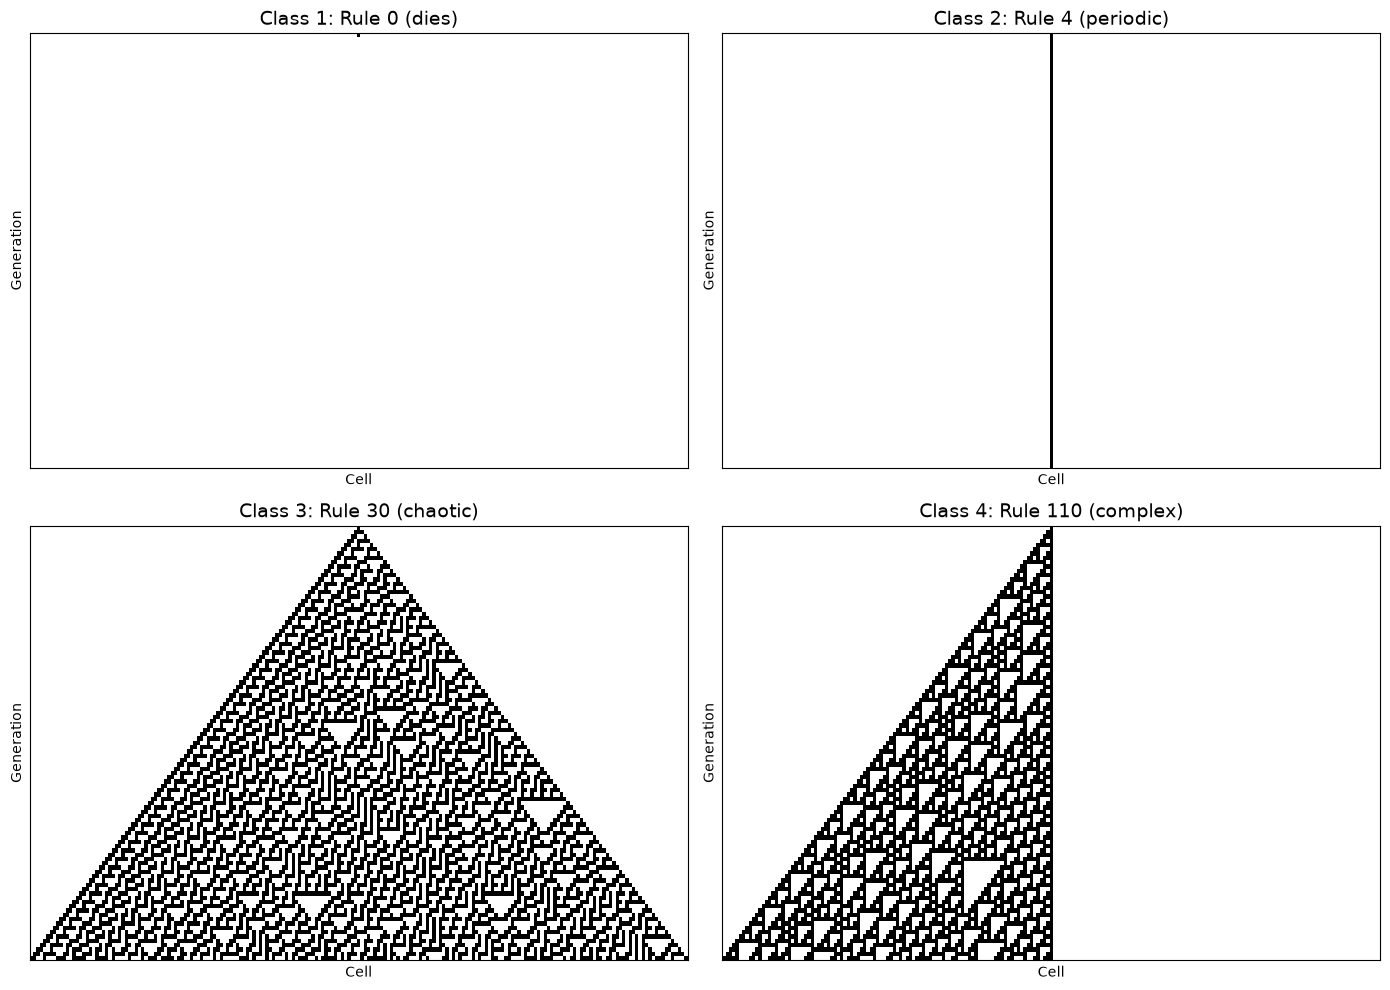

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
examples = [
    (0, "Class 1: Rule 0 (dies)"),
    (4, "Class 2: Rule 4 (periodic)"),
    (30, "Class 3: Rule 30 (chaotic)"),
    (110, "Class 4: Rule 110 (complex)"),
]
for ax, (rule, title) in zip(axes.flat, examples):
    ca = ElementaryCA(rule=rule, width=201, steps=100)
    ca.run()
    ca.plot(ax=ax, title=title)
plt.tight_layout()
plt.show()

## 5. The Interesting Ones

Some rules deserve a closer look. Each one below has a story.

### Rule 30: Chaos from Simplicity

Rule 30 is perhaps the most famous elementary automaton. It was used by Wolfram's *Mathematica*
software as a pseudo-random number generator for years. The center column alone passes
statistical randomness tests, even though the rule that generates it is completely deterministic
and fits in a single byte.

Despite the simplicity of the rule, the pattern never repeats. No one has proven this
mathematically, but billions of steps have been computed without finding a cycle.

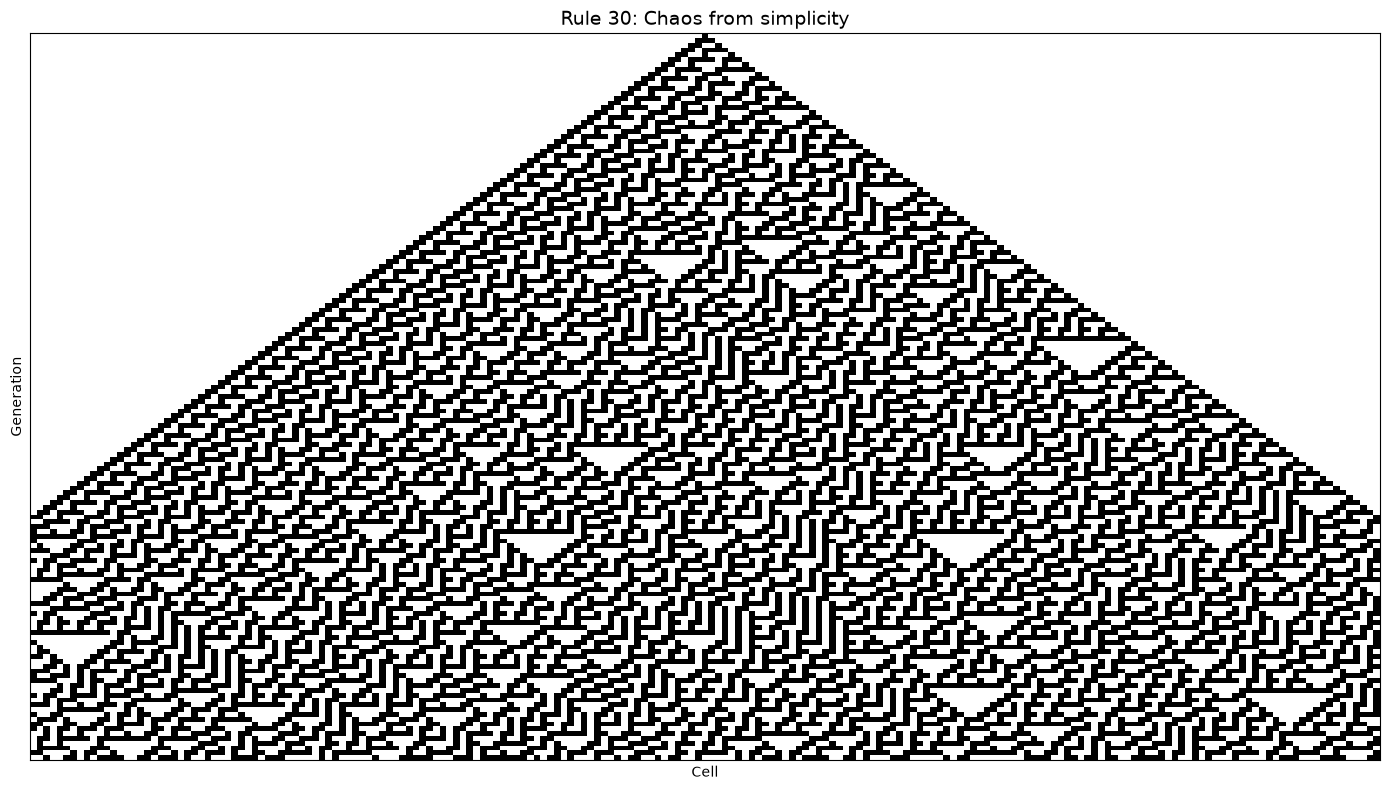

In [8]:
ca = ElementaryCA(rule=30, width=201, steps=150, init="single")
ca.run()

fig, ax = plt.subplots(figsize=(14, 8))
ca.plot(ax=ax, title="Rule 30: Chaos from simplicity")
plt.tight_layout()
plt.show()

### Rule 90: The Sierpinski Triangle

Rule 90 produces a perfect Sierpinski gasket, one of the most recognizable fractals. The rule
is equivalent to XOR of the left and right neighbors (the center cell is ignored).

The pattern is self-similar at every scale: zoom in on any triangular region and you'll see
the same structure repeated. This makes it a true fractal generated by the simplest possible process.

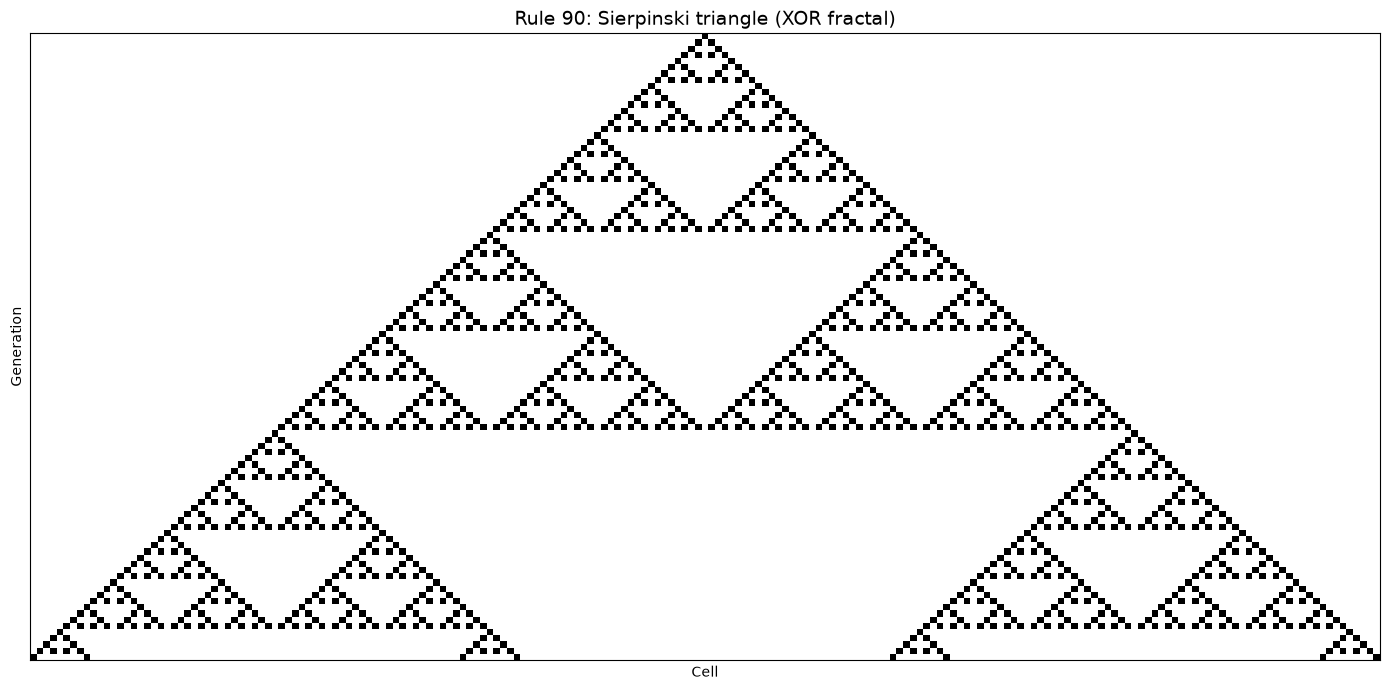

In [9]:
ca = ElementaryCA(rule=90, width=201, steps=100, init="single")
ca.run()

fig, ax = plt.subplots(figsize=(14, 7))
ca.plot(ax=ax, title="Rule 90: Sierpinski triangle (XOR fractal)")
plt.tight_layout()
plt.show()

### Rule 110: Turing Complete

Rule 110 was proven to be Turing complete by Matthew Cook in 2004. This means that with the right
initial conditions, it can simulate any computation that any computer can perform. It is the
simplest known system with this property.

From a random initial state, you can see "gliders" (small moving structures) and stationary
structures interacting with each other. These interactions are what make computation possible.

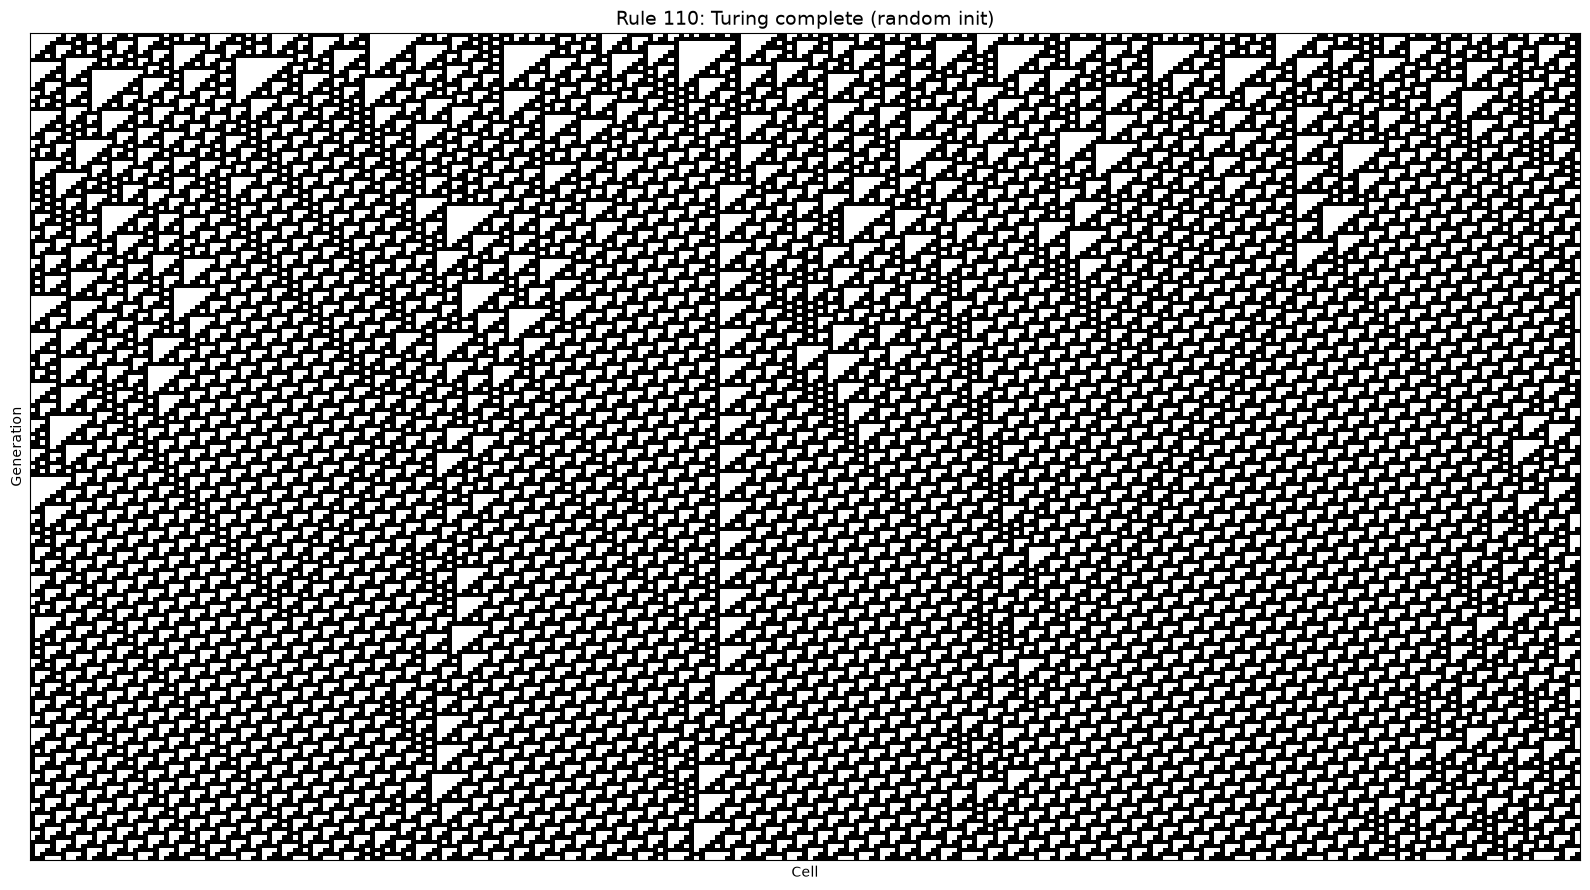

In [10]:
ca = ElementaryCA(rule=110, width=301, steps=200, init="random")
ca.run()

fig, ax = plt.subplots(figsize=(16, 9))
ca.plot(ax=ax, title="Rule 110: Turing complete (random init)")
plt.tight_layout()
plt.show()

### Rule 184: Traffic Flow

Rule 184 is a natural model of single-lane traffic. Think of each 1 as a car and each 0 as
empty road. A car moves right if the space ahead is empty; otherwise it stays put.

The behavior depends on density:
- Below 50% density: traffic flows freely, cars spread out evenly.
- Above 50% density: traffic jams form and propagate backward (leftward) as waves.
- At exactly 50%: the system is at a critical transition point.

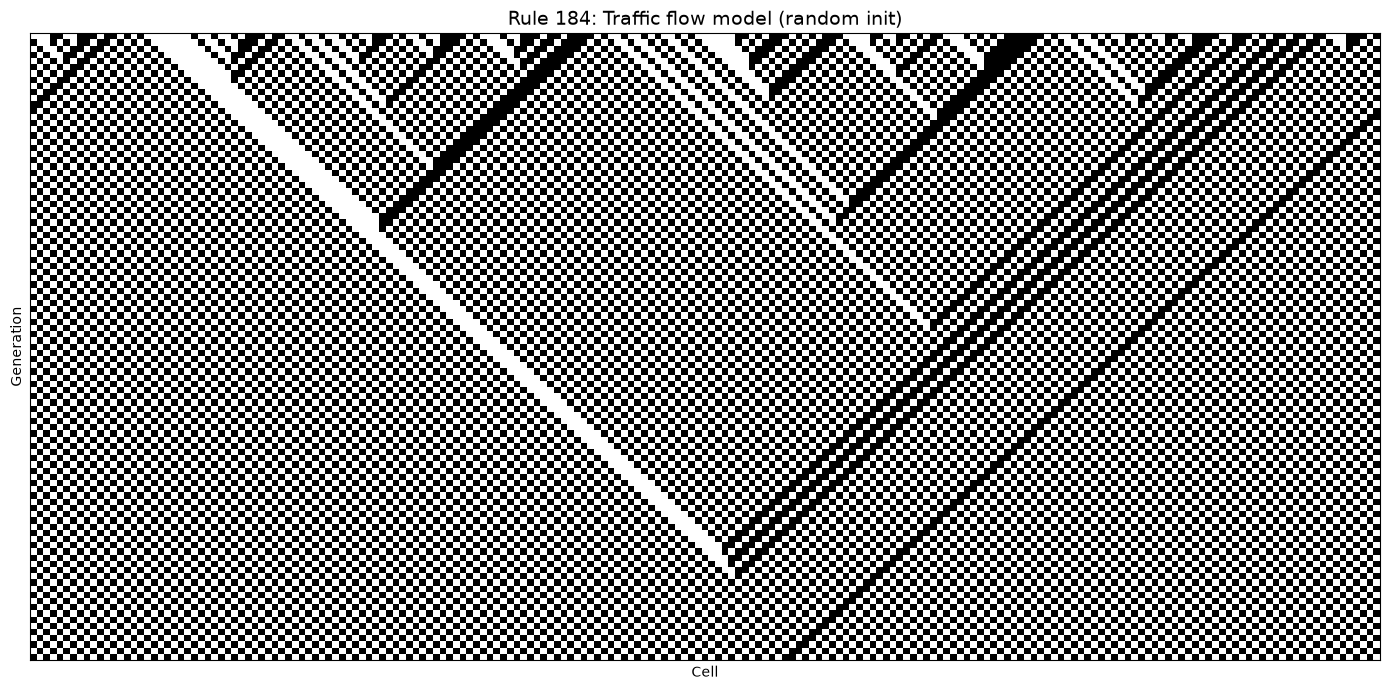

In [11]:
ca = ElementaryCA(rule=184, width=201, steps=100, init="random")
ca.run()

fig, ax = plt.subplots(figsize=(14, 7))
ca.plot(ax=ax, title="Rule 184: Traffic flow model (random init)")
plt.tight_layout()
plt.show()

### Rule 45: Class 3 Oddball

Rule 45 is chaotic like Rule 30, but it has a distinctive visual signature: triangular voids
nested within the chaotic field. From a single cell, it produces complex nested triangles that
look almost fractal but never quite repeat.

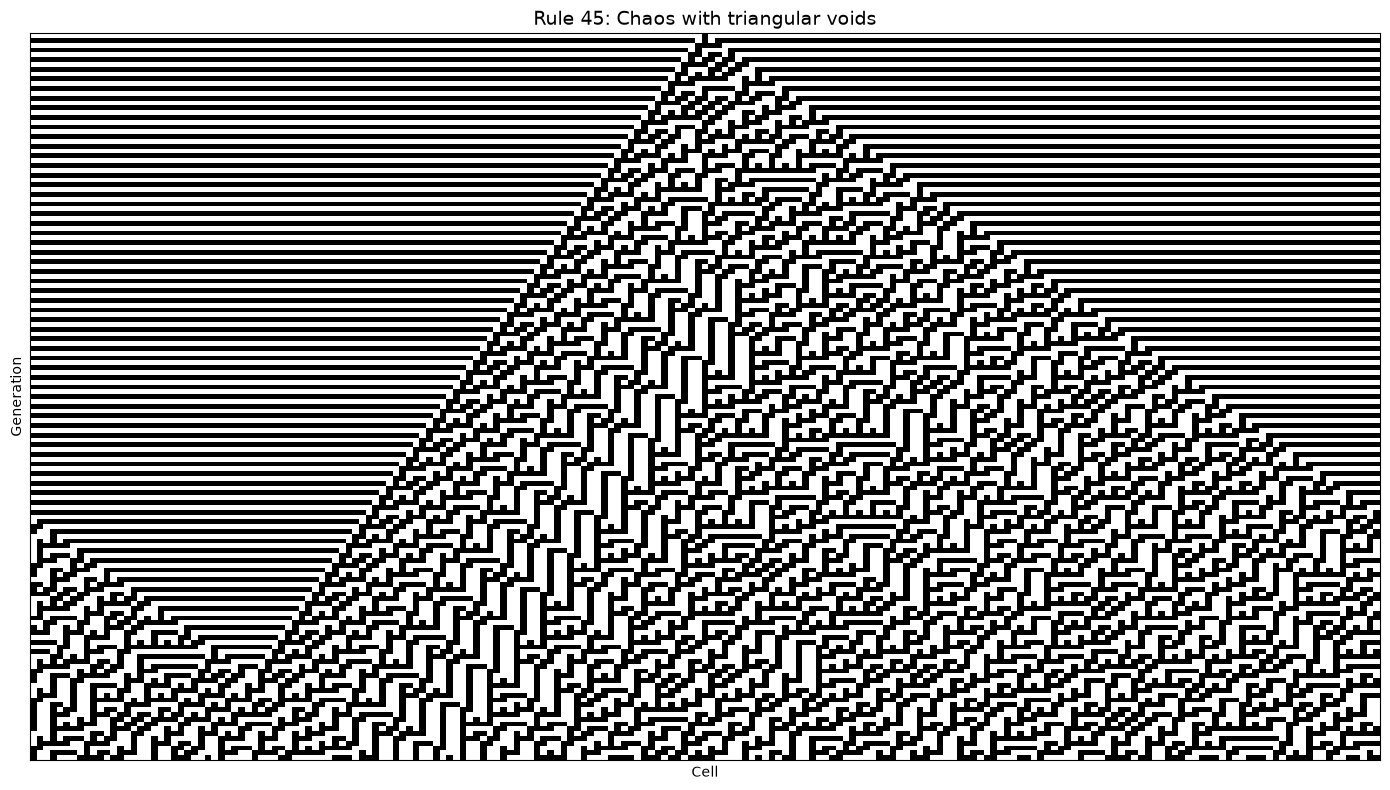

In [12]:
ca = ElementaryCA(rule=45, width=201, steps=150, init="single")
ca.run()

fig, ax = plt.subplots(figsize=(14, 8))
ca.plot(ax=ax, title="Rule 45: Chaos with triangular voids")
plt.tight_layout()
plt.show()

### Rule 73: Rare Structure

Rule 73 produces unusual diagonal striping and localized structures, especially visible from
a random initial condition. Let's compare both starting modes side by side.

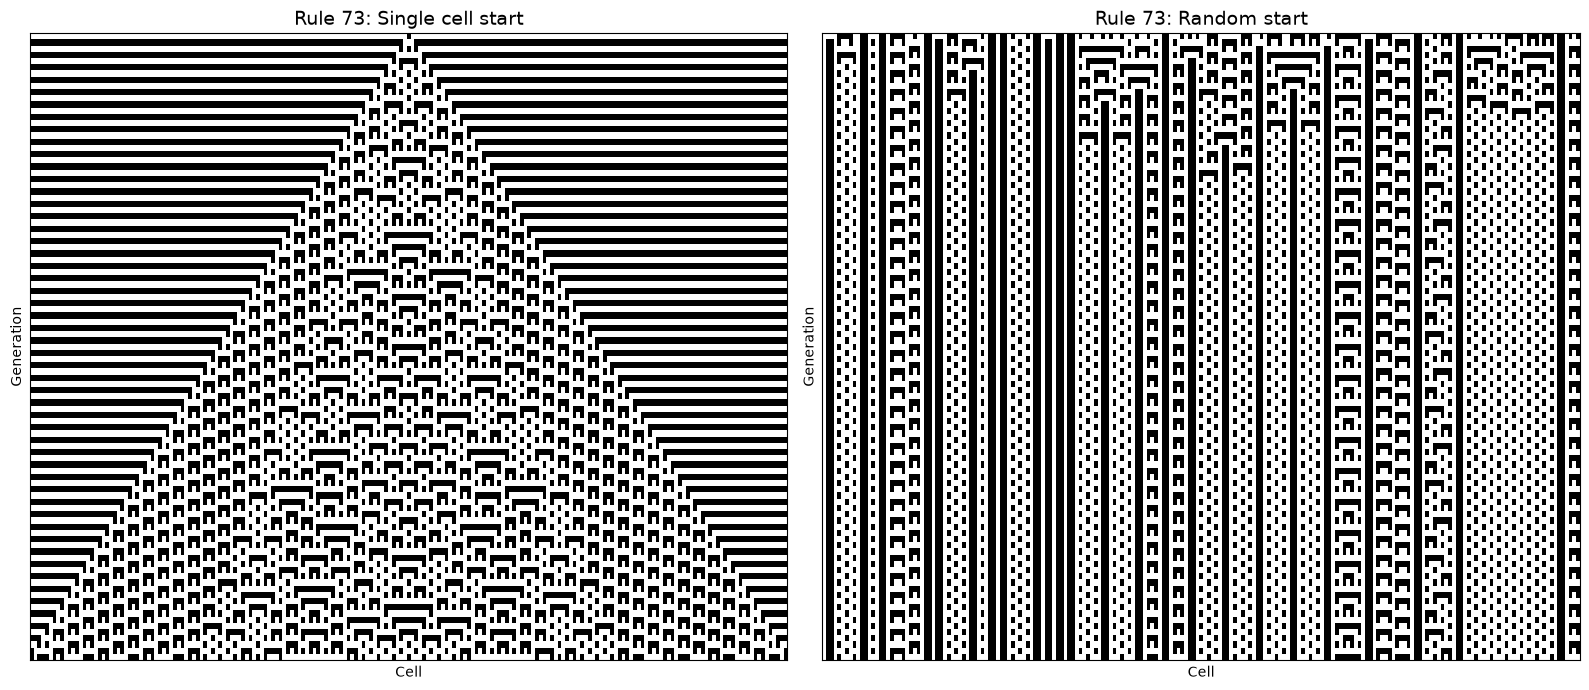

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ca_single = ElementaryCA(rule=73, width=201, steps=100, init="single")
ca_single.run()
ca_single.plot(ax=axes[0], title="Rule 73: Single cell start")

ca_random = ElementaryCA(rule=73, width=201, steps=100, init="random")
ca_random.run()
ca_random.plot(ax=axes[1], title="Rule 73: Random start")

plt.tight_layout()
plt.show()

## 6. Density Evolution

One way to characterize a rule's behavior is to track the **density**: the fraction of live cells
in each generation. Different classes have distinctive density signatures:

- Class 1 rules drive density to 0 (or 1).
- Class 2 rules stabilize at a fixed density.
- Class 3 rules fluctuate around 0.5.
- Class 4 rules show complex, irregular density changes.

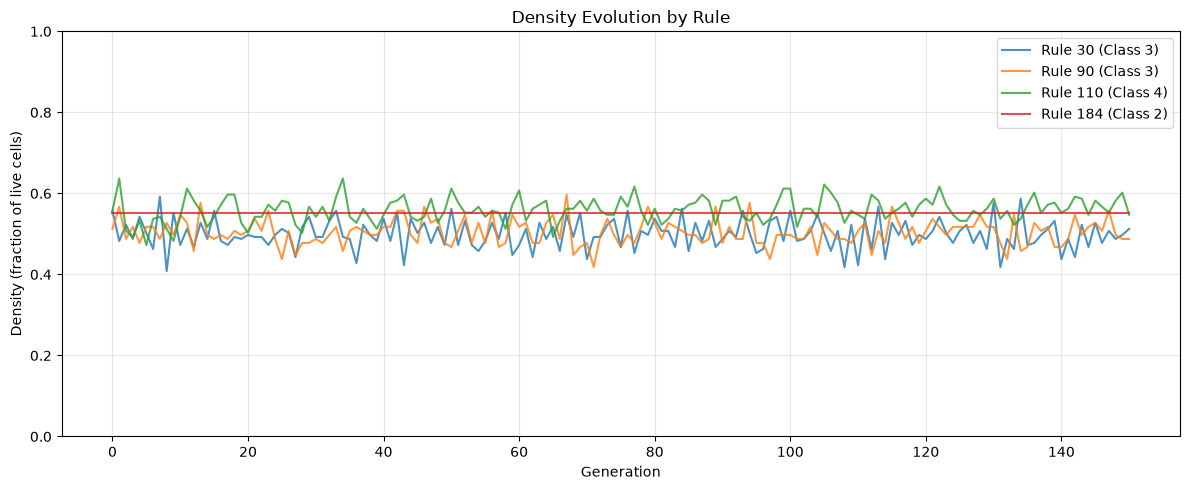

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

rules_to_plot = [
    (30, "Rule 30 (Class 3)"),
    (90, "Rule 90 (Class 3)"),
    (110, "Rule 110 (Class 4)"),
    (184, "Rule 184 (Class 2)"),
]

for rule, label in rules_to_plot:
    ca = ElementaryCA(rule=rule, width=201, steps=150, init="random")
    ca.run()
    ax.plot(ca.density, label=label, alpha=0.8)

ax.set_xlabel("Generation")
ax.set_ylabel("Density (fraction of live cells)")
ax.set_title("Density Evolution by Rule")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. All 256 Rules at a Glance

Here's the full catalog: every one of the 256 elementary cellular automata, each started from
a single center cell. Use this as a map to find interesting rules, then explore them with the
interactive widget above.

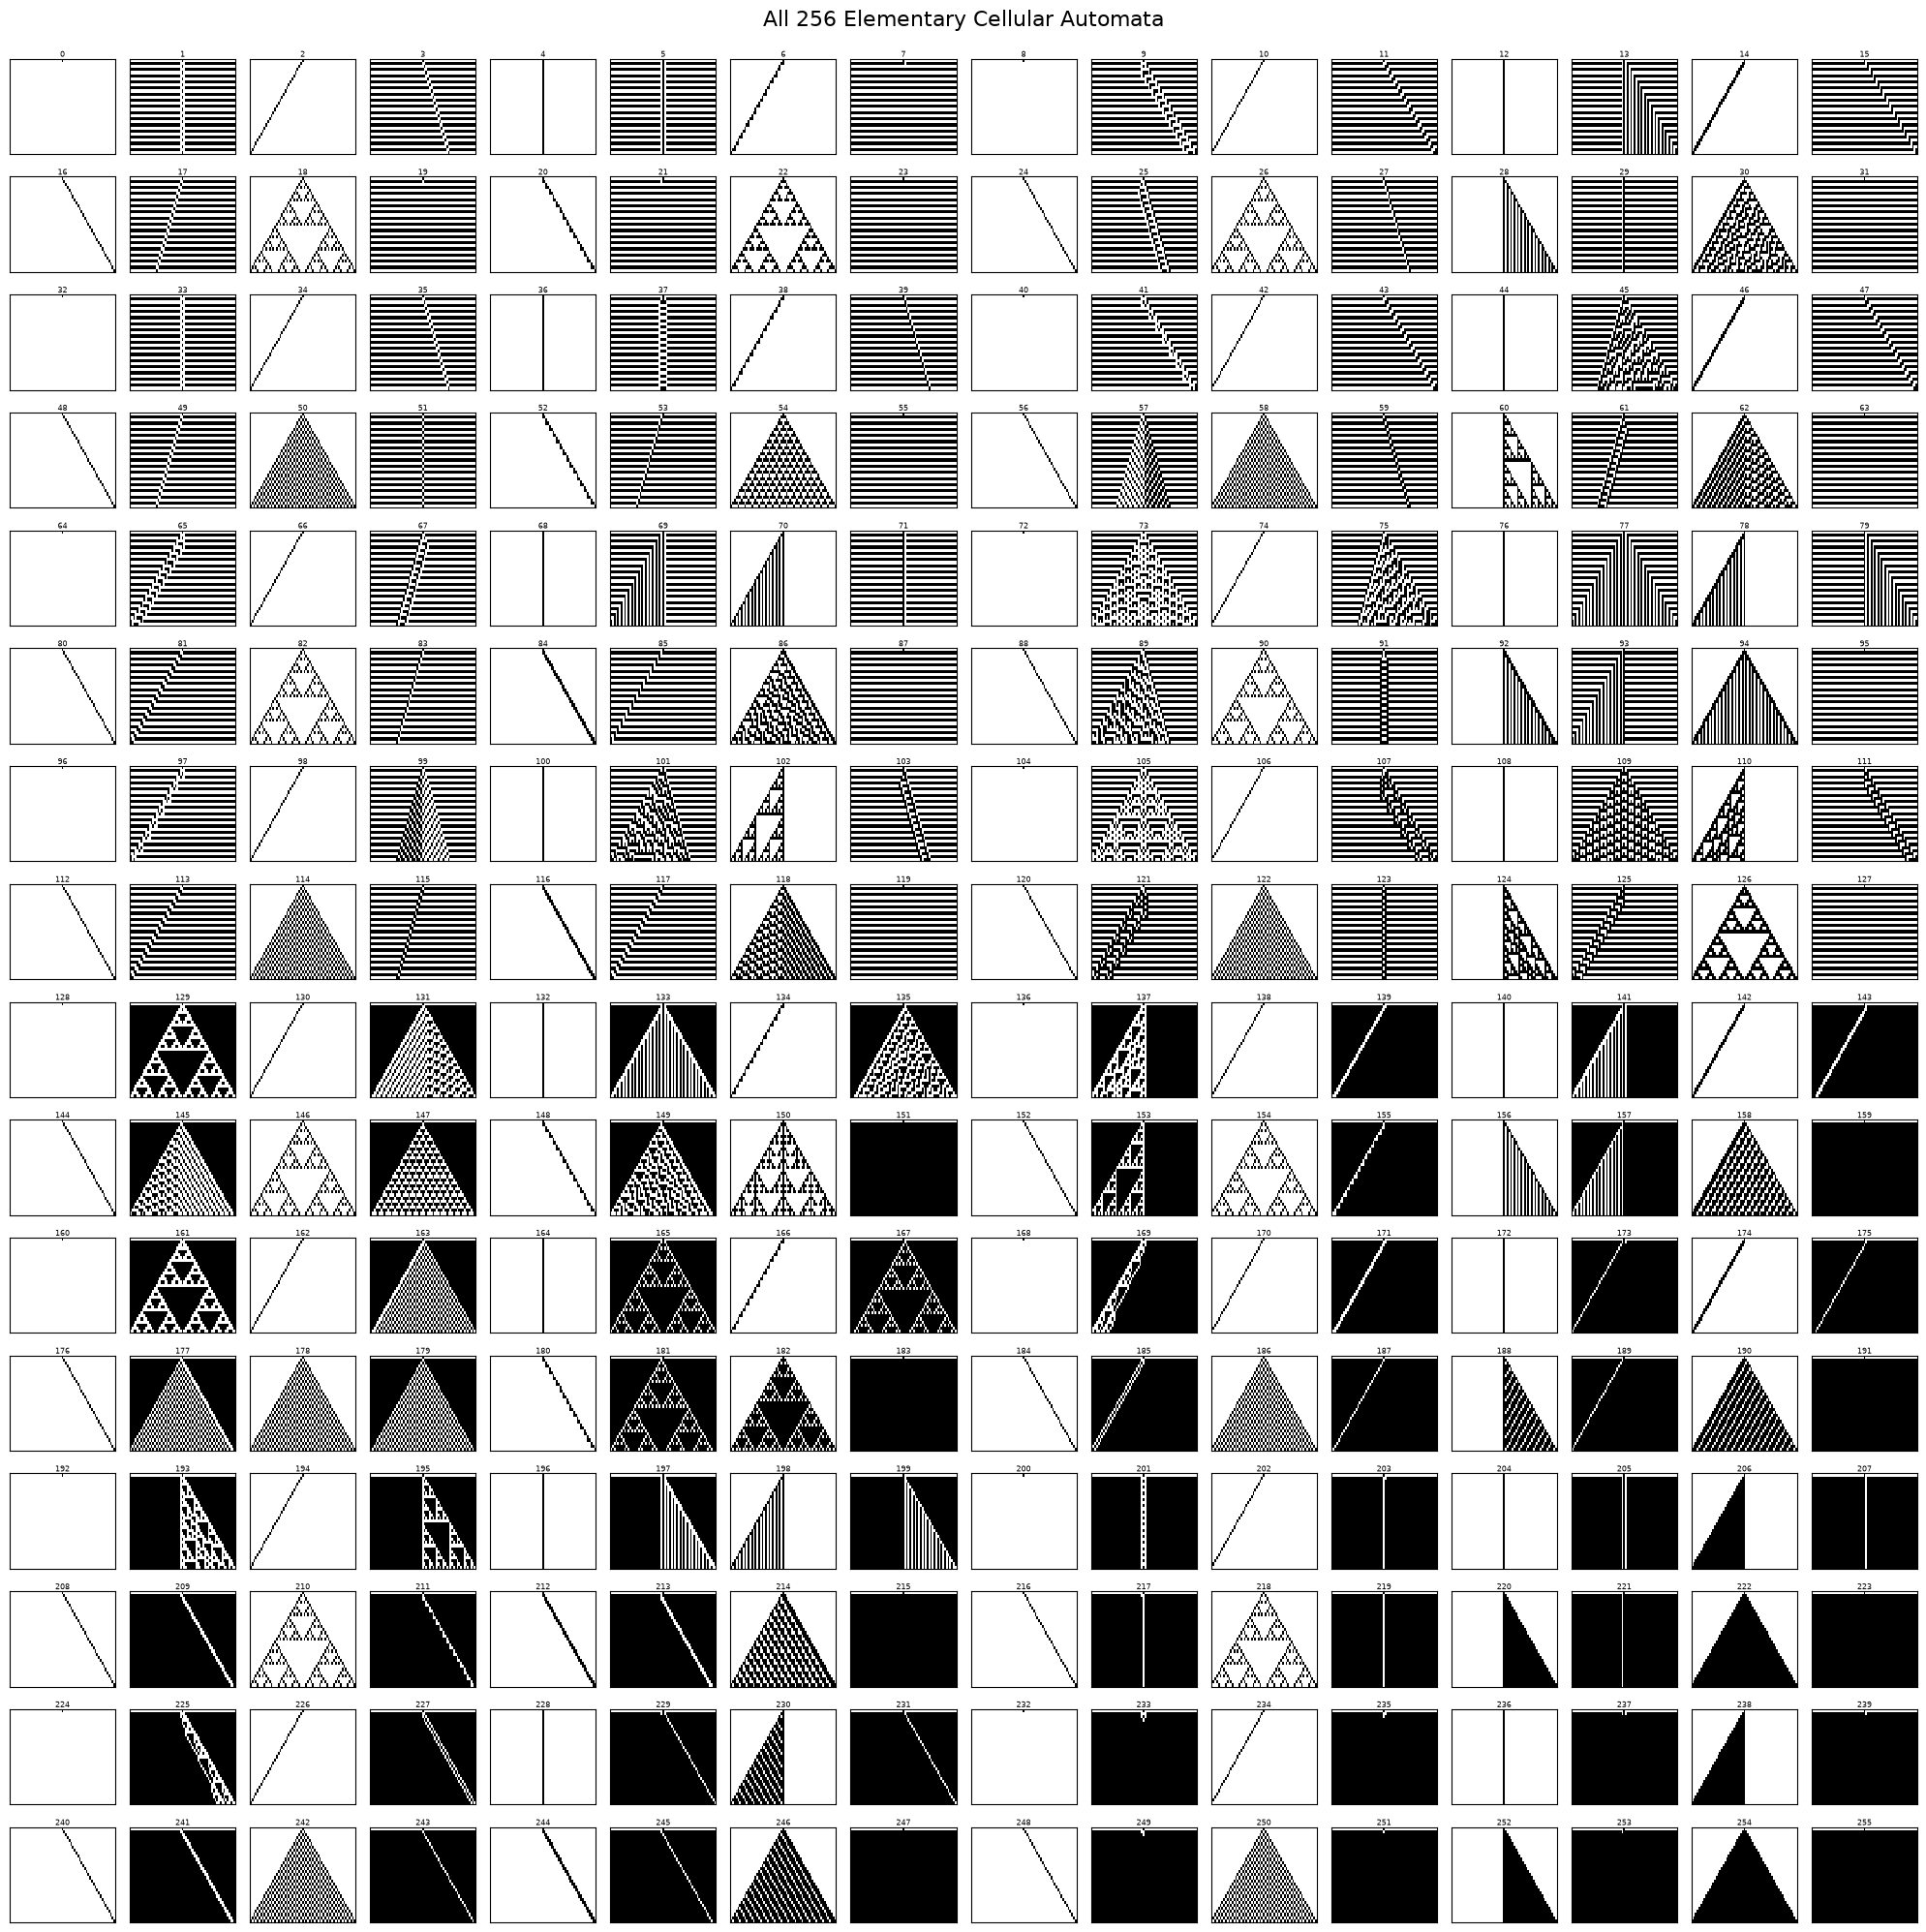

In [15]:
fig, axes = plt.subplots(16, 16, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    ca = ElementaryCA(rule=i, width=61, steps=30)
    ca.run()
    ax.imshow(ca.grid, cmap="binary", interpolation="nearest", aspect="auto")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(str(i), fontsize=6, pad=1)
plt.suptitle("All 256 Elementary Cellular Automata", fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

## 8. Next Steps

Elementary cellular automata are just the beginning. Here are some directions to explore:

- **2D automata**: Conway's Game of Life extends this idea to a grid where each cell has 8
  neighbors. The result is an incredibly rich universe of patterns, including self-replicating
  structures and working computers.

- **Totalistic rules**: Instead of looking at exact neighbor patterns, count the number of
  live neighbors. This allows more than 2 states and produces smooth, organic-looking patterns.

- **Continuous automata**: Replace discrete 0/1 states with continuous values (0.0 to 1.0).
  The result looks like reaction-diffusion systems and can model real chemistry.

- **Procedural generation**: Game developers use cellular automata to generate cave systems,
  terrain, and organic textures. The simplicity of the rules makes them fast and easy to tune.

The deep lesson of cellular automata is that complexity does not require complex rules. Simple
local interactions, repeated many times, can produce behavior as rich as anything in nature.